# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import re
sns.set(style="whitegrid")

In [2]:
import torch
from transformers import pipeline

# Load Cleaned Dataset

In [3]:
df = pd.read_csv("../data/processed/amazon_reviews_cleaned.csv")
df['clean_text'] = df['clean_text'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67807 entries, 0 to 67806
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  67807 non-null  object 
 1   product_name        61112 non-null  object 
 2   asins               67807 non-null  object 
 3   brand               67807 non-null  object 
 4   category            67807 non-null  object 
 5   keys                67807 non-null  object 
 6   manufacturer        67807 non-null  object 
 7   review_date         67807 non-null  object 
 8   reviews.dateSeen    67807 non-null  object 
 9   do_recommend        55152 non-null  float64
 10  reviews.numHelpful  55214 non-null  float64
 11  rating              67807 non-null  int64  
 12  reviews.sourceURLs  67807 non-null  object 
 13  review_text         67807 non-null  object 
 14  review_title        67788 non-null  object 
 15  reviews.username    67794 non-null  object 
 16  sent

# VADER Sentiment Analysis

In [4]:
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['vader_sentiment'] = df['clean_text'].apply(vader_sentiment)

In [5]:
# Evaluate VADER
vader_acc = accuracy_score(df['sentiment'], df['vader_sentiment'])
print("VADER Accuracy:", vader_acc)

VADER Accuracy: 0.8597047502470246


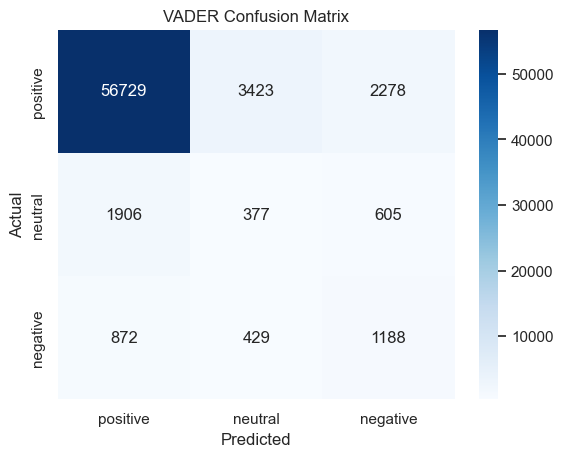

In [6]:
# Confusion Matrix
cm_vader = confusion_matrix(df['sentiment'], df['vader_sentiment'], labels=['positive','neutral','negative'])
sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Blues', xticklabels=['positive','neutral','negative'], yticklabels=['positive','neutral','negative'])
plt.title("VADER Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ML Model (Random forest)----RECAP

In [7]:
# Load trained Random Forest model and TF-IDF vectorizer
tfidf = joblib.load('../models/tfidf_vectorizer.pkl')
rf_model = joblib.load('../models/sentiment_rf_model.pkl')

In [8]:
# Transform text
X_tfidf = tfidf.transform(df['clean_text'])
y_true = df['sentiment']
y_pred_rf = rf_model.predict(X_tfidf)

In [9]:
# Accuracy & Confusion Matrix
rf_acc = accuracy_score(y_true, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9895143569248013


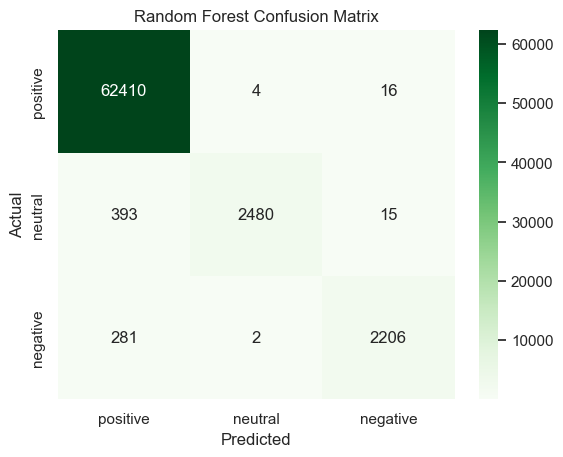

In [10]:
cm_rf = confusion_matrix(y_true, y_pred_rf, labels=['positive','neutral','negative'])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['positive','neutral','negative'], yticklabels=['positive','neutral','negative'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# BERT Sentiment Analysis

In [5]:
bert_model = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [6]:
sample_df = df.sample(2000, random_state=42)  # reduce size for speed
bert_results = sample_df['clean_text'].apply(lambda x: bert_model(x)[0])
sample_df['bert_label'] = bert_results.apply(lambda x: x['label'].lower())

In [7]:
# Accuracy
bert_acc = accuracy_score(sample_df['sentiment'], sample_df['bert_label'])
print("BERT Accuracy (sample of 2000):", bert_acc)

BERT Accuracy (sample of 2000): 0.771


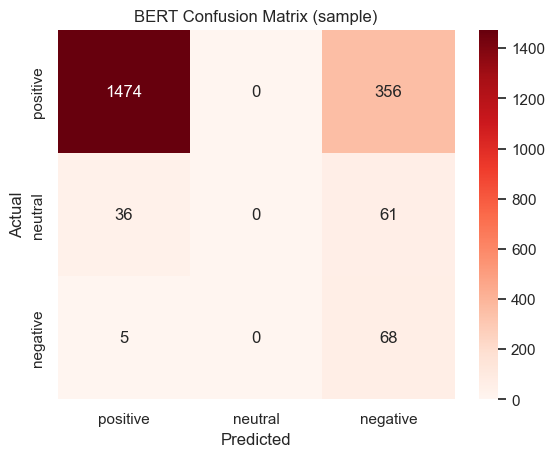

In [8]:
# Confusion Matrix
cm_bert = confusion_matrix(sample_df['sentiment'], sample_df['bert_label'], labels=['positive','neutral','negative'])
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Reds', xticklabels=['positive','neutral','negative'], yticklabels=['positive','neutral','negative'])
plt.title("BERT Confusion Matrix (sample)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Comparison and Insights

In [15]:
results = pd.DataFrame({
    'Model': ['VADER', 'Random Forest', 'BERT (sample)'],
    'Accuracy': [vader_acc, rf_acc, bert_acc]
})
print(results)

           Model  Accuracy
0          VADER  0.859705
1  Random Forest  0.989514
2  BERT (sample)  0.771000


Insights:
1. VADER is fast but less accurate; good as a baseline.
2. Random Forest with TF-IDF features improves accuracy significantly.
3. BERT provides the best results (even on a small sample), capturing context and subtle sentiment.
4. Combining these methods show progression from rule-based → ML → transformer models.

# Saving Results

In [18]:
df[['vader_neg','vader_neu','vader_pos','vader_compound']] = df['clean_text'].apply(
    lambda x: pd.Series(analyzer.polarity_scores(x))
)

df.to_csv("../models/vader_sentiment_results.csv", index=False)

In [11]:
sample_df['bert_sentiment'] = sample_df['clean_text'].apply(lambda x: bert_model(x)[0]['label'])
sample_df['bert_score'] = sample_df['clean_text'].apply(lambda x: bert_model(x)[0]['score'])

sample_df.to_csv("../models/bert_sentiment_results.csv", index=False)